 Loading the Taxis Dataset

In [ ]:
import seaborn as sns

df = sns.load_dataset("taxis")
print(df.head())

               pickup             dropoff  passengers  distance  fare   tip  \
0 2019-03-23 20:21:09 2019-03-23 20:27:24           1      1.60   7.0  2.15   
1 2019-03-04 16:11:55 2019-03-04 16:19:00           1      0.79   5.0  0.00   
2 2019-03-27 17:53:01 2019-03-27 18:00:25           1      1.37   7.5  2.36   
3 2019-03-10 01:23:59 2019-03-10 01:49:51           1      7.70  27.0  6.15   
4 2019-03-30 13:27:42 2019-03-30 13:37:14           3      2.16   9.0  1.10   

   tolls  total   color      payment            pickup_zone  \
0    0.0  12.95  yellow  credit card        Lenox Hill West   
1    0.0   9.30  yellow         cash  Upper West Side South   
2    0.0  14.16  yellow  credit card          Alphabet City   
3    0.0  36.95  yellow  credit card              Hudson Sq   
4    0.0  13.40  yellow  credit card           Midtown East   

            dropoff_zone pickup_borough dropoff_borough  
0    UN/Turtle Bay South      Manhattan       Manhattan  
1  Upper West Side South      

2. Handling Missing Values

Check for missing values in the dataset and identify columns with missing data.

In [ ]:
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64


 Impute missing values using appropriate strategies based on the column type (e.g.,using mean, median, or mode for numerical columns, and mode for categorical columns).

In [ ]:
df["tip"] = df["tip"].fillna(df["tip"].median())
df["tolls"] = df["tolls"].fillna(df["tolls"].median())

df["color"] = df["color"].fillna(df["color"].mode()[0])
df["payment"] = df["payment"].fillna(df["payment"].mode()[0])
df["dropoff_zone"] = df["dropoff_zone"].fillna(df["dropoff_zone"].mode()[0])
df["dropoff_borough"] = df["dropoff_borough"].fillna(df["dropoff_borough"].mode()[0])

print(df.isnull().sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment             0
pickup_zone        26
dropoff_zone        0
pickup_borough     26
dropoff_borough     0
dtype: int64


For columns that are critical and cannot be reasonably imputed, remove rows with missing values to maintain data integrity.

In [ ]:
df = df.dropna(subset=["dropoff_zone", "dropoff_borough"])

print(df.isnull().sum())

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment             0
pickup_zone        26
dropoff_zone        0
pickup_borough     26
dropoff_borough     0
dtype: int64


3. Visualizations using Matplotlib/Pandas Plot:
★ Line Chart  
Plot a line chart to visualize the fare over time, using the pickup timestamp as the
x-axis and fare as the y-axis. Ensure the pickup column is converted to a datetime
format before plotting.

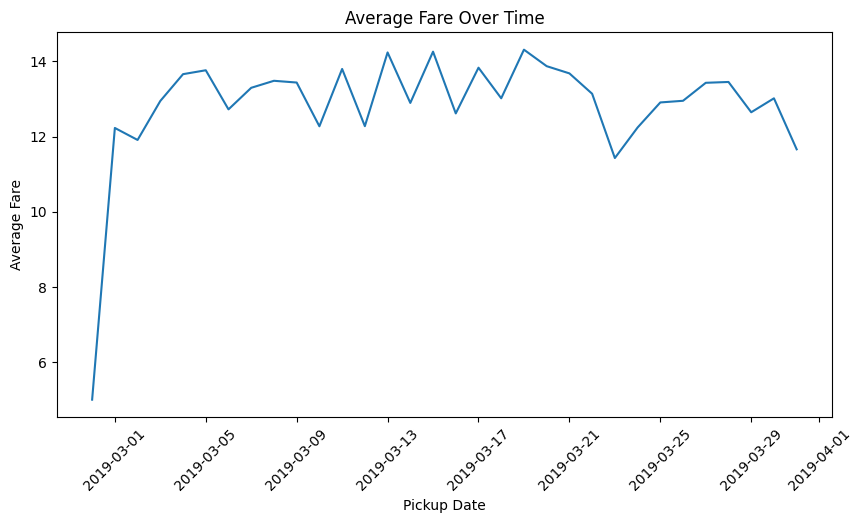

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df["pickup"] = pd.to_datetime(df["pickup"])

df["pickup_date"] = df["pickup"].dt.date

avg_fare = df.groupby("pickup_date")["fare"].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_fare.index, avg_fare.values)

plt.xlabel("Pickup Date")
plt.ylabel("Average Fare")
plt.title("Average Fare Over Time")
plt.xticks(rotation=45)

plt.show()

Bar Chart  
Create a bar chart to show the total fare for each pickup_borough. Group the data by pickup_borough and sum the fare for each group.

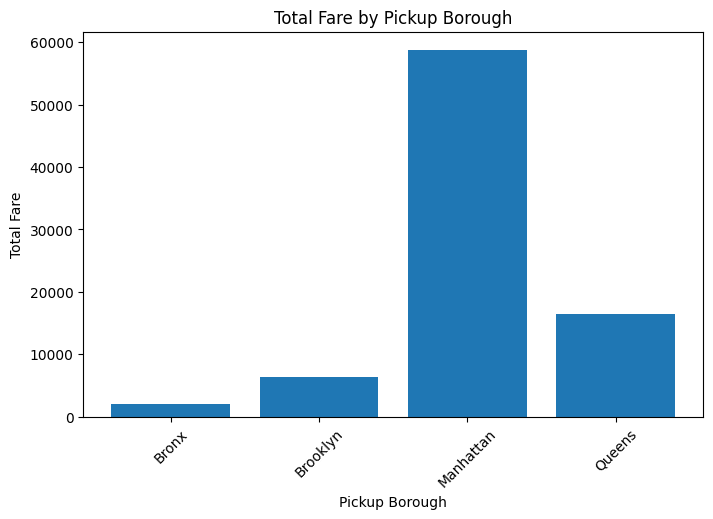

In [ ]:
borough_fare = df.groupby("pickup_borough")["fare"].sum()

plt.figure(figsize=(8,5))
plt.bar(borough_fare.index, borough_fare.values)

plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")
plt.title("Total Fare by Pickup Borough")

plt.xticks(rotation=45)
plt.show()

Pie Chart  
Plot a pie chart showing the distribution of trips based on the payment method (credit card, cash, etc.). Each slice should represent the count of trips for a specific payment method.

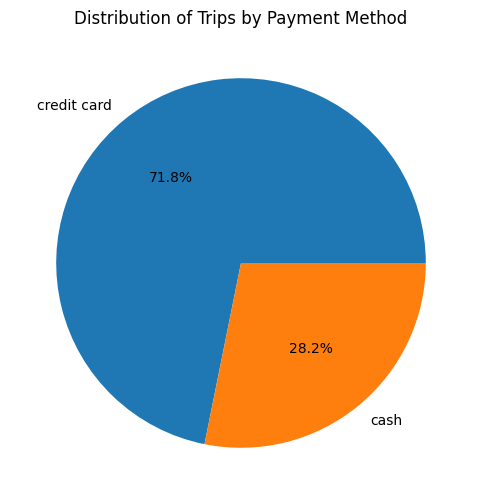

In [ ]:
payment_count = df["payment"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(payment_count, labels=payment_count.index, autopct="%1.1f%%")

plt.title("Distribution of Trips by Payment Method")

plt.show()

Histogram  
Create a histogram to visualize the distribution of distance. Customize the number of
bins for better granularity and ensure the plot is easy to interpret.

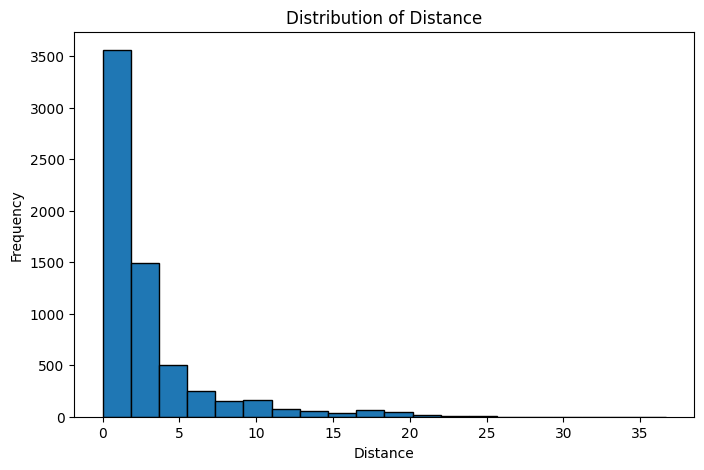

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df["distance"], bins=20,edgecolor="black")

plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.title("Distribution of Distance")

plt.show()

Box Plot  
Plot a box plot to visualize the distribution of tip amounts for each pickup_borough.Use pickup_borough as the categorical axis and tip as the numeric axis.

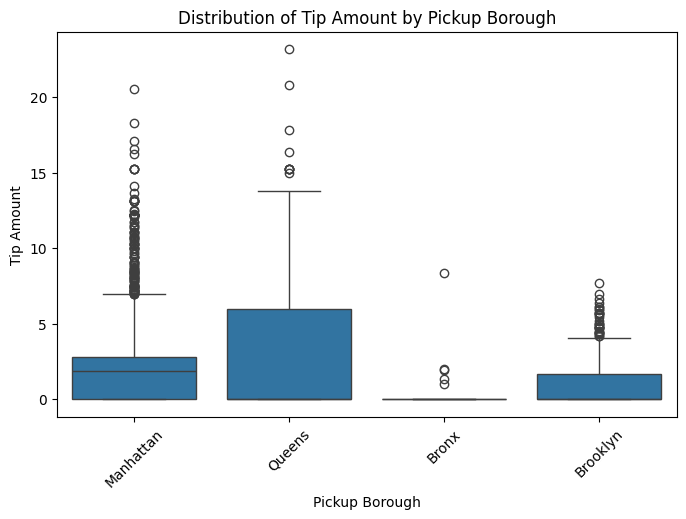

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="pickup_borough", y="tip", data=df)

plt.xlabel("Pickup Borough")
plt.ylabel("Tip Amount")
plt.title("Distribution of Tip Amount by Pickup Borough")

plt.xticks(rotation=45)
plt.show()

Visualizations using Seaborn:
★ Count Plot  
Create a count plot to visualize the number of trips in each pickup_borough. The x-axis should represent the boroughs, and the y-axis should show the count of trips.

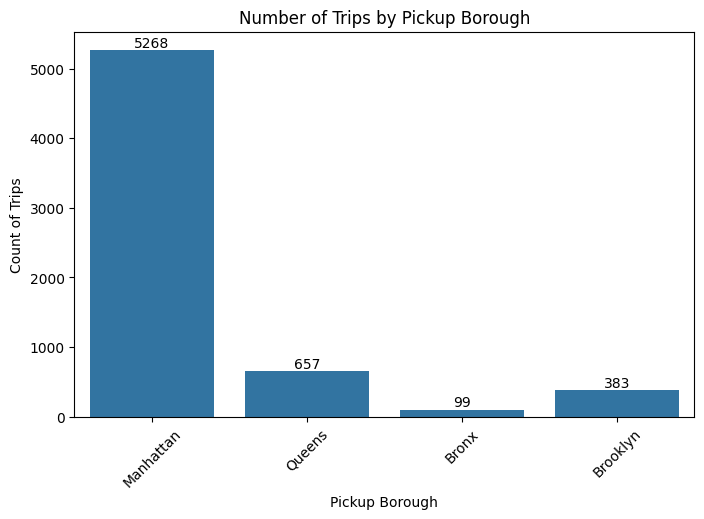

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x="pickup_borough", data=df)

for container in ax.containers:
    ax.bar_label(container)

plt.xlabel("Pickup Borough")
plt.ylabel("Count of Trips")
plt.title("Number of Trips by Pickup Borough")
plt.xticks(rotation=45)
plt.show()

Scatter Plot  
Plot a scatter plot to show the relationship between distance and fare. Use
distance on the x-axis and fare on the y-axis to visualize any correlation. Color the
points based on the pickup_borough to differentiate the trips by their respective
boroughs.

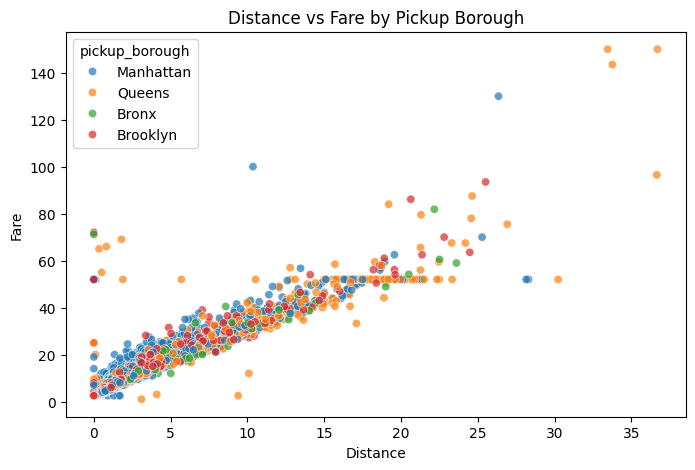

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="distance",
    y="fare",
    hue="pickup_borough",
    data=df,
    alpha=0.7
)

plt.xlabel("Distance")
plt.ylabel("Fare")
plt.title("Distance vs Fare by Pickup Borough")
plt.show()

Heatmap  
Plot a heatmap to visualize the correlation between numerical variables such as
distance, fare, tip, tolls, and total. Use a correlation matrix to highlight the
relationships.

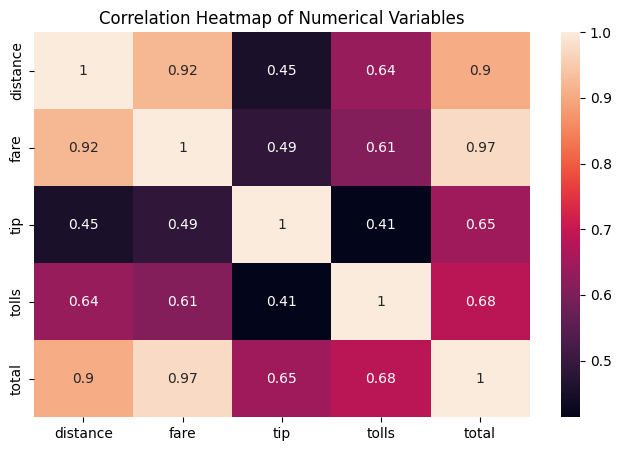

In [ ]:
num_cols = df[["distance", "fare", "tip", "tolls", "total"]]

corr_matrix = num_cols.corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr_matrix, annot=True)

plt.title("Correlation Heatmap of Numerical Variables")

plt.show()

Pair Plot  
Create a pair plot to visualize the pairwise relationships between distance, fare, tip,
and total. Color the data points according to the pickup_zone method to compare
how different zones affect these variables.

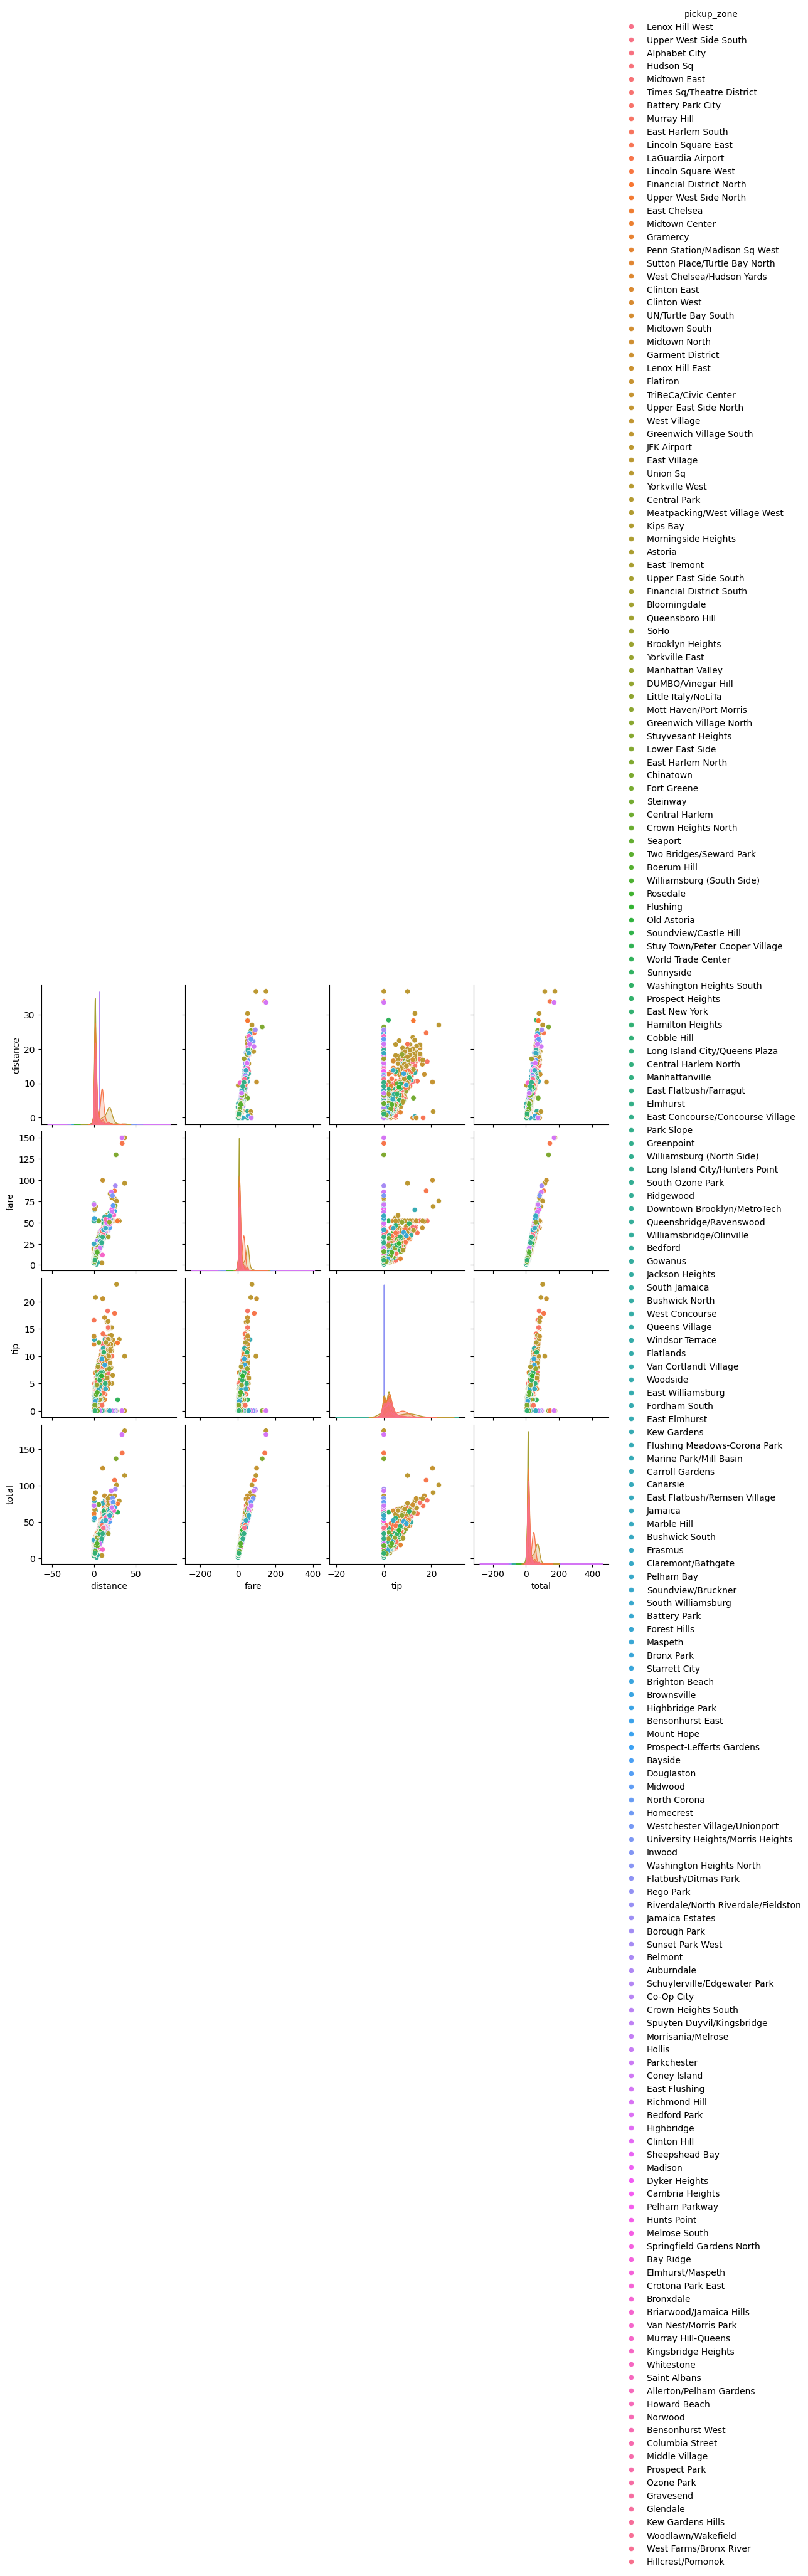

In [ ]:
sns.pairplot(
    df,
    vars=["distance", "fare", "tip", "total"],
    hue="pickup_zone"
)

plt.show()

Violin Plot  
Plot a violin plot to show the distribution of fare for each payment method. Use the
payment method as the categorical axis and fare as the numeric axis to visualize its
distribution.

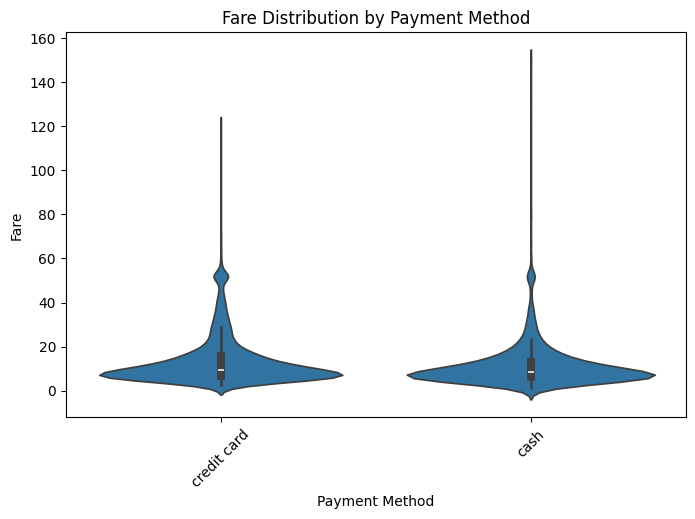

In [ ]:
plt.figure(figsize=(8,5))
sns.violinplot(x="payment", y="fare", data=df, inner="box")

plt.xlabel("Payment Method")
plt.ylabel("Fare")
plt.title("Fare Distribution by Payment Method")
plt.xticks(rotation=45)

plt.show()